# sales forecasting and bussiness analysis with machine learning.
This project analyzes historical sales data, performs exploratory data analysis (EDA), and builds machine learning models to forecast future sales.

## 1)import libraries

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# 2)load the dataset

In [7]:
train = pd.read_csv("dataset/train.csv", low_memory=False)
store = pd.read_csv("dataset/store.csv")

## 3)merge the datasets


In [8]:
# Merge train and store datasets using Store as the common key
df = pd.merge(train, store, on="Store", how="left")

In [9]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [10]:
print("Merged Dataset Shape:", df.shape)

Merged Dataset Shape: (1017209, 18)


## 4) data understanding


In [11]:
# Dataset dimensions
print("Rows and Columns:", df.shape)

Rows and Columns: (1017209, 18)


In [12]:
# Column names
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [13]:
# Data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [14]:
# Statistical summary
df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000


## 5) Exploratory Data Analysis(EDA)
first EDA question:
How is sales distributed?

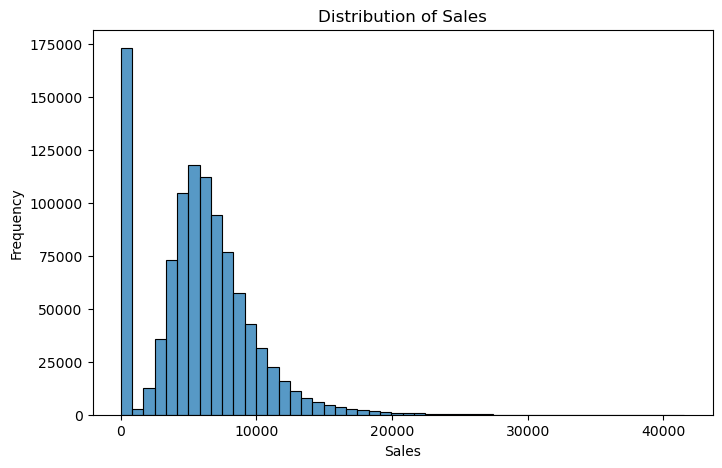

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], bins=50)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

Second EDA question:Are there any missing values?


In [16]:
df.isnull().sum().sort_values(ascending=False)

PromoInterval                508031
Promo2SinceYear              508031
Promo2SinceWeek              508031
CompetitionOpenSinceYear     323348
CompetitionOpenSinceMonth    323348
CompetitionDistance            2642
DayOfWeek                         0
Promo2                            0
Assortment                        0
Store                             0
SchoolHoliday                     0
StateHoliday                      0
Promo                             0
Open                              0
Customers                         0
Sales                             0
Date                              0
StoreType                         0
dtype: int64

In [18]:
df["Promo2"].value_counts()

Promo2
1    509178
0    508031
Name: count, dtype: int64

# duplicate records?

In [19]:
df.duplicated().sum()

0

No duplicate records were found in the dataset.

## Correlation heatmap:

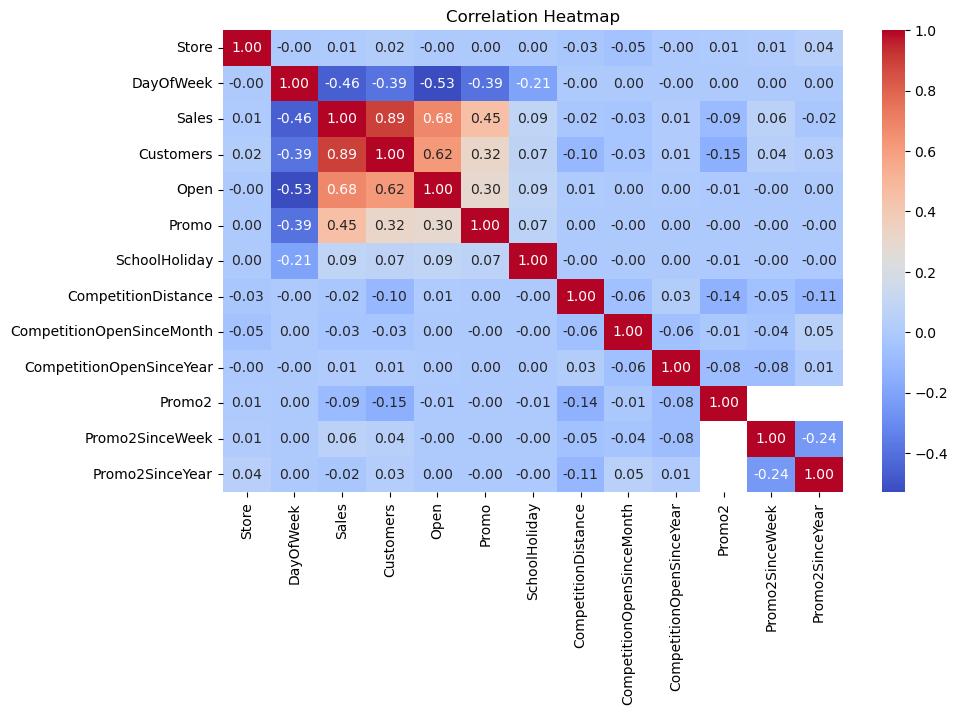

In [20]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

### Observations

- Customers show a very strong positive correlation (0.89) with Sales.
- Stores that are open tend to generate higher sales.
- Promotional campaigns have a moderate positive relationship with sales.
- Sales vary across different days of the week.
- Competition distance has very little linear relationship with sales.
- School holidays have only a weak impact on sales.

# Sales by Store Type

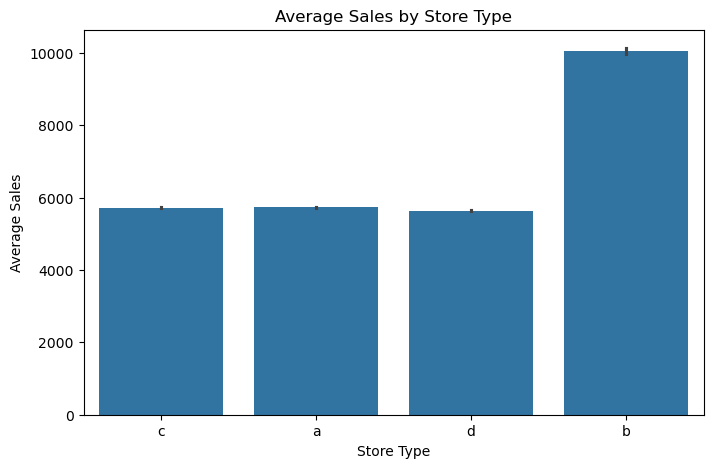

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(x="StoreType", y="Sales", data=df)

plt.title("Average Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")

plt.show()


# **Observation:**

- Store Type B records the highest average sales among all store types.
- Store Types A, C, and D have relatively similar average sales.
- The store type appears to have a significant impact on sales performance.

# IMPACT OF PROMOTIONS ON SALES

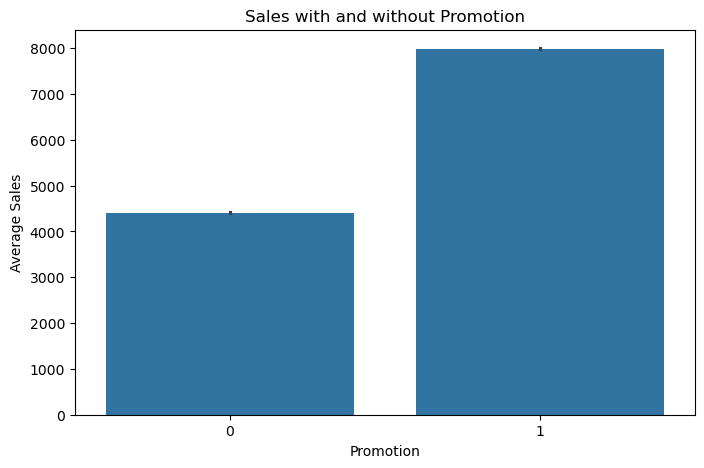

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(x="Promo", y="Sales", data=df)

plt.title("Sales with and without Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Sales")

plt.show()

**Observation:**

Promotions have a significant impact on sales, cause higher sales

# Sales by Day of Week

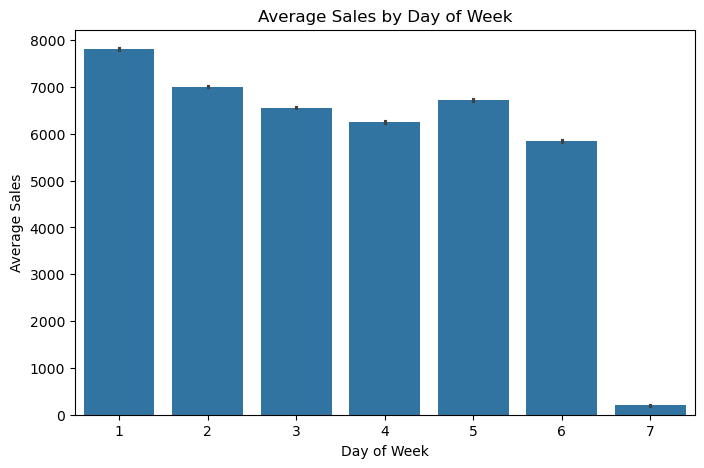

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(x="DayOfWeek", y="Sales", data=df)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")

plt.show()

**Observation:**

- Day 1 records the highest average sales.
- Sales generally decline toward the end of the week.
- Day 7 has extremely low sales because many stores remain closed on Sundays.

# Montly sales trend:


In [24]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month

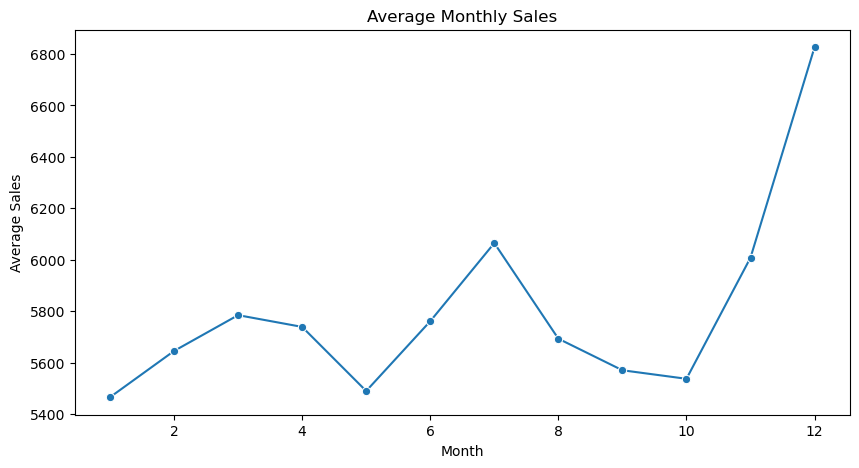

In [27]:
monthly_sales = df.groupby("Month")["Sales"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(data=monthly_sales, x="Month", y="Sales", marker="o")

plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

**Observation:**

- Average sales remain fairly consistent throughout most of the year.
- Sales increase during July and peak in December.
- The strong performance in November and December indicates seasonal shopping trends.

## 6. Data Cleaning

In [29]:
df["Date"] = pd.to_datetime(df["Date"])

In [30]:
df.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
Month                             0
dtype: int64

In [31]:
# Competition Distance
df["CompetitionDistance"] = df["CompetitionDistance"].fillna(df["CompetitionDistance"].median())

# Competition information
df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].fillna(0)
df["CompetitionOpenSinceYear"] = df["CompetitionOpenSinceYear"].fillna(0)

# Promo2 information
df["Promo2SinceWeek"] = df["Promo2SinceWeek"].fillna(0)
df["Promo2SinceYear"] = df["Promo2SinceYear"].fillna(0)
df["PromoInterval"] = df["PromoInterval"].fillna("No Promo")

In [32]:
df.isnull().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
Month                        0
dtype: int64

## 7. Feature Engineering

In [35]:
# Extract date-related features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Week"] = df["Date"].dt.isocalendar().week

In [36]:
# Weekend indicator
df["IsWeekend"] = df["DayOfWeek"].isin([6, 7]).astype(int)

In [37]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Month,IsWeekend,Year,Day,Week
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,2008.0,0,0.0,0.0,No Promo,7,0,2015,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",7,0,2015,31,31
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",7,0,2015,31,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,2009.0,0,0.0,0.0,No Promo,7,0,2015,31,31
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,2015.0,0,0.0,0.0,No Promo,7,0,2015,31,31


## 8. Encoding Categorical Features

In [38]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    "StateHoliday",
    "StoreType",
    "Assortment",
    "PromoInterval"
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [39]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Month,IsWeekend,Year,Day,Week
0,1,5,2015-07-31,5263,555,1,1,0,1,2,...,2008.0,0,0.0,0.0,3,7,0,2015,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,0,...,2007.0,1,13.0,2010.0,1,7,0,2015,31,31
2,3,5,2015-07-31,8314,821,1,1,0,1,0,...,2006.0,1,14.0,2011.0,1,7,0,2015,31,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,2,...,2009.0,0,0.0,0.0,3,7,0,2015,31,31
4,5,5,2015-07-31,4822,559,1,1,0,1,0,...,2015.0,0,0.0,0.0,3,7,0,2015,31,31


## 9. Prepare Features and Target

In [40]:
# Features
X = df.drop(columns=["Sales", "Date"])

# Target
y = df["Sales"]

In [41]:
print(X.shape)
print(y.shape)

X.head()

(1017209, 21)
(1017209,)


,Store,DayOfWeek,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Month,IsWeekend,Year,Day,Week
0,1,5,555,1,1,0,1,2,0,1270.0,...,2008.0,0,0.0,0.0,3,7,0,2015,31,31
1,2,5,625,1,1,0,1,0,0,570.0,...,2007.0,1,13.0,2010.0,1,7,0,2015,31,31
2,3,5,821,1,1,0,1,0,0,14130.0,...,2006.0,1,14.0,2011.0,1,7,0,2015,31,31
3,4,5,1498,1,1,0,1,2,2,620.0,...,2009.0,0,0.0,0.0,3,7,0,2015,31,31
4,5,5,559,1,1,0,1,0,0,29910.0,...,2015.0,0,0.0,0.0,3,7,0,2015,31,31


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (813767, 21)
Testing Set: (203442, 21)


## 10. Model Training

In [43]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [44]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [45]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

## 11. Model Evaluation

In [46]:
# Predictions
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

In [47]:
print("----- Linear Regression -----")
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R² Score:", r2_score(y_test, lr_pred))

----- Linear Regression -----
MAE : 940.9371297580605
RMSE: 1391.961843947987
R² Score: 0.8689847535604808


In [48]:
print("\n----- Random Forest -----")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R² Score:", r2_score(y_test, rf_pred))


----- Random Forest -----
MAE : 263.4119179422144
RMSE: 439.4841910397867
R² Score: 0.9869396838032893


In [49]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,Customers,0.857934
7,StoreType,0.033302
9,CompetitionDistance,0.028984
4,Promo,0.018037
0,Store,0.016587
13,Promo2SinceWeek,0.006768
11,CompetitionOpenSinceYear,0.005846
8,Assortment,0.005819
10,CompetitionOpenSinceMonth,0.005657
1,DayOfWeek,0.005087


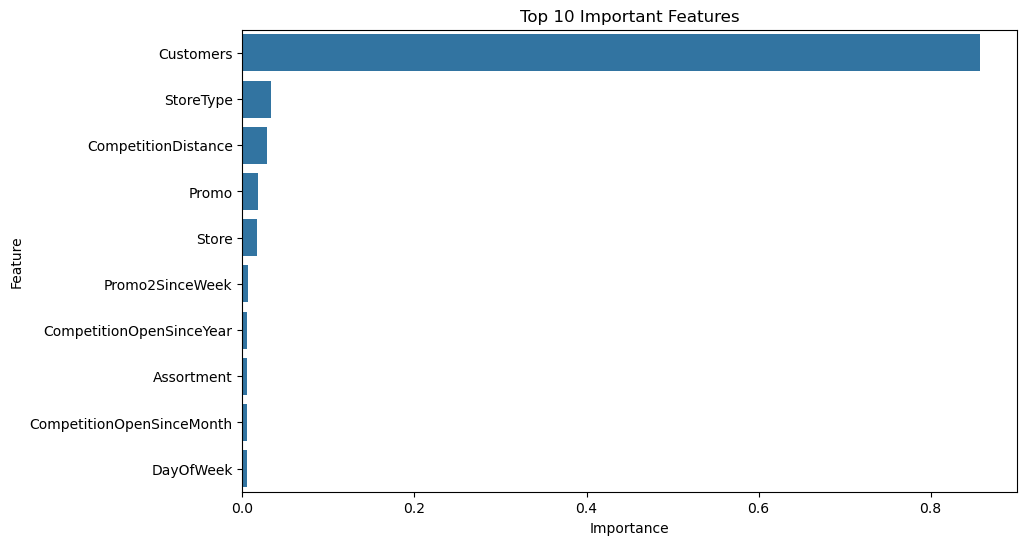

In [50]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

### Model Comparison

Two regression models were trained and evaluated:

| Model | MAE | RMSE | R² Score |
|-------|------:|------:|---------:|
| Linear Regression | 940.94 | 1391.96 | 0.869 |
| Random Forest Regressor | 263.41 | 439.48 | 0.987 |

### Observation

- Random Forest Regressor outperformed Linear Regression across all evaluation metrics.
- It achieved a much lower prediction error (MAE and RMSE).
- The Random Forest model explained approximately **98.7%** of the variance in sales, making it the preferred model for sales forecasting.

# Conclusion

In this project, historical Rossmann store sales data was analyzed to identify the factors influencing sales and to build predictive models.

The project involved:
- Data cleaning
- Exploratory Data Analysis (EDA)
- Feature engineering
- Model training and evaluation

Among the two models tested, Random Forest Regressor achieved the best performance with an R² score of **0.987**, significantly outperforming Linear Regression.

This project demonstrates the complete machine learning workflow for a business forecasting problem and highlights how promotions, customer count, store type, and seasonal trends influence sales.